# Ames Housing - Exploratory Data Analysis
The Primary objective of this notebook is to analyze factors influencing house prices and understand key drivers of SalePrice.

## 0: Imports and Reading Data

In [196]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 200)

In [197]:
df = pd.read_csv('AmesHousing.csv')

## 1: Data Understanding

In [198]:
df.shape

(2930, 82)

In [199]:
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Heating,Heating QC,Central Air,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112.0,TA,TA,CBlock,TA,Gd,Gd,BLQ,639.0,Unf,0.0,441.0,1080.0,GasA,Fa,Y,SBrkr,1656,0,0,1656,1.0,0.0,1,0,3,1,TA,7,Typ,2,Gd,Attchd,1960.0,Fin,2.0,528.0,TA,TA,P,210,62,0,0,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,7,5,1968,1968,Hip,CompShg,BrkFace,BrkFace,NaN,0.0,Gd,TA,CBlock,TA,TA,No,ALQ,1065.0,Unf,0.0,1045.0,2110.0,GasA,Ex,Y,SBrkr,2110,0,0,2110,1.0,0.0,2,1,3,1,Ex,8,Typ,2,TA,Attchd,1968.0,Fin,2.0,522.0,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [261]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Overall_Qual    2930 non-null   int64  
 1   Gr_Liv_Area     2930 non-null   int64  
 2   Garage_Cars     2929 non-null   float64
 3   Garage_Area     2929 non-null   float64
 4   Total_Bsmt_SF   2929 non-null   float64
 5   1st_Flr_SF      2930 non-null   int64  
 6   Year_Built      2930 non-null   int64  
 7   Full_Bath       2930 non-null   int64  
 8   Year_Remod_Add  2930 non-null   int64  
 9   Garage_Yr_Blt   2771 non-null   float64
 10  Mas_Vnr_Area    2907 non-null   float64
 11  TotRms_AbvGrd   2930 non-null   int64  
 12  Neighborhood    2930 non-null   str    
 13  Exter_Qual      2930 non-null   str    
 14  Kitchen_Qual    2930 non-null   str    
 15  Sale_Price      2930 non-null   int64  
dtypes: float64(5), int64(8), str(3)
memory usage: 366.4 KB


### Observations

- The dataset contains 2930 rows and 82 columns.
- There are 39 numerical features and 43 categorical features.
- Some columns contain missing values, particularly Alley, Pool QC, Fence and Misc Feature.
- The average SalePrice is 180k.
- Initial inspection suggests that SalePrice has a wide range and may contain high-value outliers.

## 2: Data Preperation

In [204]:
# Drop obvious useless columns
df = df.drop(["Order", "PID"], axis=1)

# Select 12 numeric features with highest correlation with SalePrice
corr = df.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False)
top_num = corr[1:13].index

# Add important categorical features
df = df[list(top_num)+ ['Neighborhood', 'Exter Qual', 'Kitchen Qual', 'SalePrice']]

In [205]:
# Rename columns to Capital_Second style (e.g., "Overall Qual" -> "Overall_Qual")
df = df.rename(columns={
  'Overall Qual': 'Overall_Qual',
  'Gr Liv Area': 'Gr_Liv_Area',
  'Garage Cars': 'Garage_Cars',
  'Garage Area': 'Garage_Area',
  'Total Bsmt SF': 'Total_Bsmt_SF',
  '1st Flr SF': '1st_Flr_SF',
  'Year Built': 'Year_Built',
  'Full Bath': 'Full_Bath',
  'Year Remod/Add': 'Year_Remod_Add',
  'Garage Yr Blt': 'Garage_Yr_Blt',
  'Mas Vnr Area': 'Mas_Vnr_Area',
  'TotRms AbvGrd': 'TotRms_AbvGrd',
  'Neighborhood': 'Neighborhood',
  'Exter Qual': 'Exter_Qual',
  'Kitchen Qual': 'Kitchen_Qual',
  'SalePrice' : 'Sale_Price'
})

df.columns

Index(['Overall_Qual', 'Gr_Liv_Area', 'Garage_Cars', 'Garage_Area',
       'Total_Bsmt_SF', '1st_Flr_SF', 'Year_Built', 'Full_Bath',
       'Year_Remod_Add', 'Garage_Yr_Blt', 'Mas_Vnr_Area', 'TotRms_AbvGrd',
       'Neighborhood', 'Exter_Qual', 'Kitchen_Qual', 'Sale_Price'],
      dtype='str')

In [206]:
df.isnull().sum()

Overall_Qual        0
Gr_Liv_Area         0
Garage_Cars         1
Garage_Area         1
Total_Bsmt_SF       1
1st_Flr_SF          0
Year_Built          0
Full_Bath           0
Year_Remod_Add      0
Garage_Yr_Blt     159
Mas_Vnr_Area       23
TotRms_AbvGrd       0
Neighborhood        0
Exter_Qual          0
Kitchen_Qual        0
Sale_Price          0
dtype: int64

## 3: Feature Understanding (Univariate Analysis)

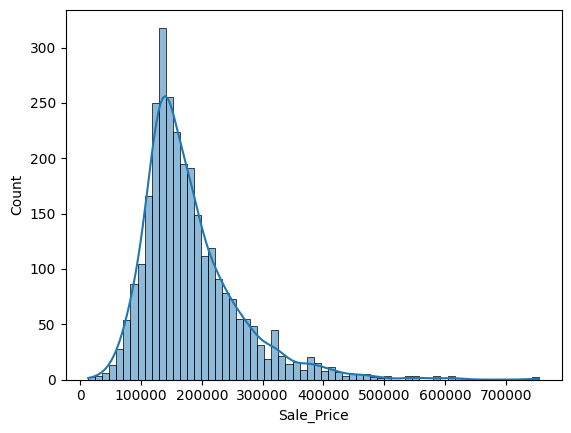

In [207]:
sns.histplot(df['Sale_Price'], kde=True)
plt.show()

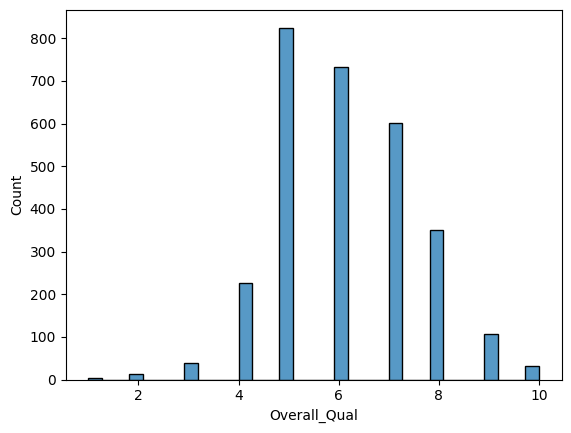

In [208]:
sns.histplot(df['Overall_Qual'])
plt.show()

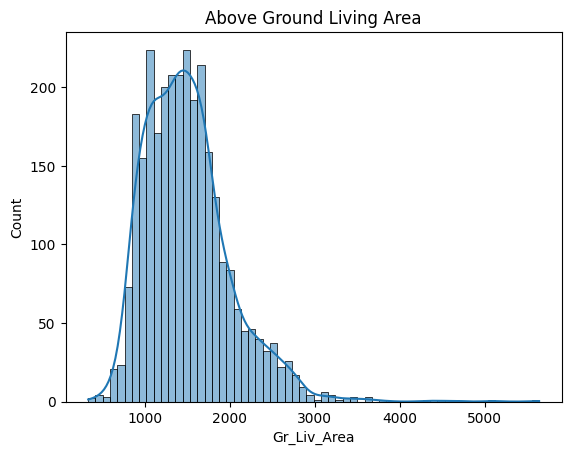

In [209]:
sns.histplot(df['Gr_Liv_Area'], kde=True)
plt.title('Above Ground Living Area')
plt.show()


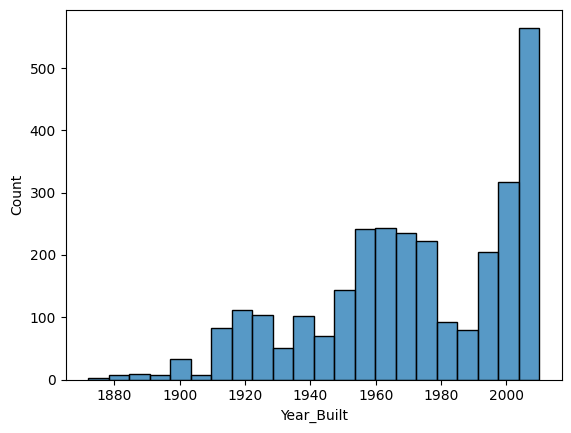

In [210]:
sns.histplot(df['Year_Built'])
plt.show()

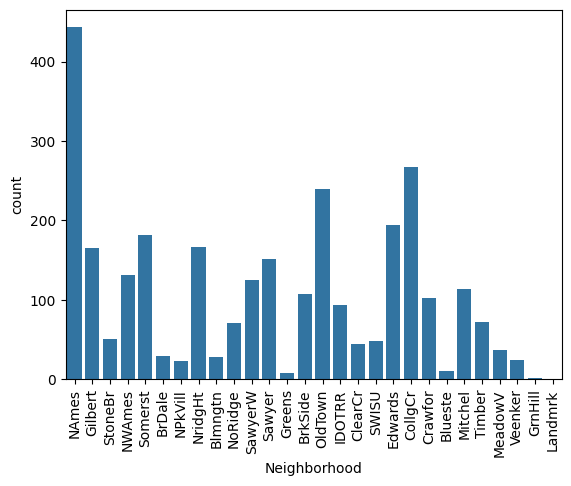

In [211]:
sns.countplot(x='Neighborhood', data=df)
plt.xticks(rotation=90)
plt.show()

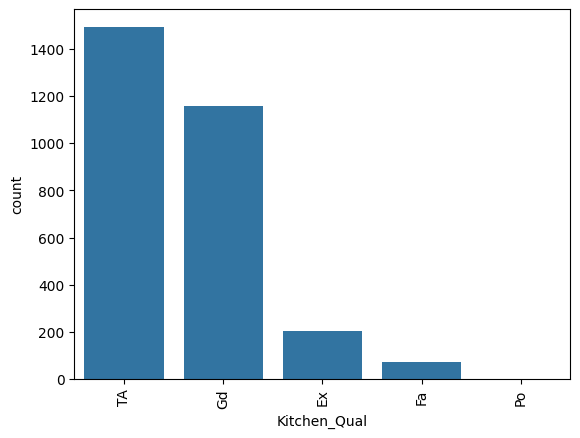

In [212]:
sns.countplot(x='Kitchen_Qual', data=df)
plt.xticks(rotation=90)
plt.show()

### Insights:
- Sales_Price is right skewed with outliers above 500k.
- Above ground living area is also right skewed with outliers above 4000.
- From 1900 to 2000 The number of house built has increased over the years.
- Most of the houses in the dataset are from NAmes neighbourhood 
- Kitchen Quality for most houses is TA meaning Typical.

## 4: Bivariate Analysis

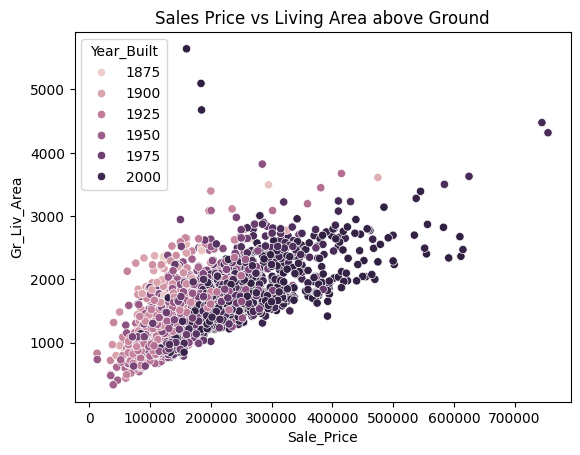

In [219]:
sns.scatterplot(
        x='Sale_Price',
        y='Gr_Liv_Area',
        hue='Year_Built',
        data =df)
plt.title('Sales Price vs Living Area above Ground')
plt.show()

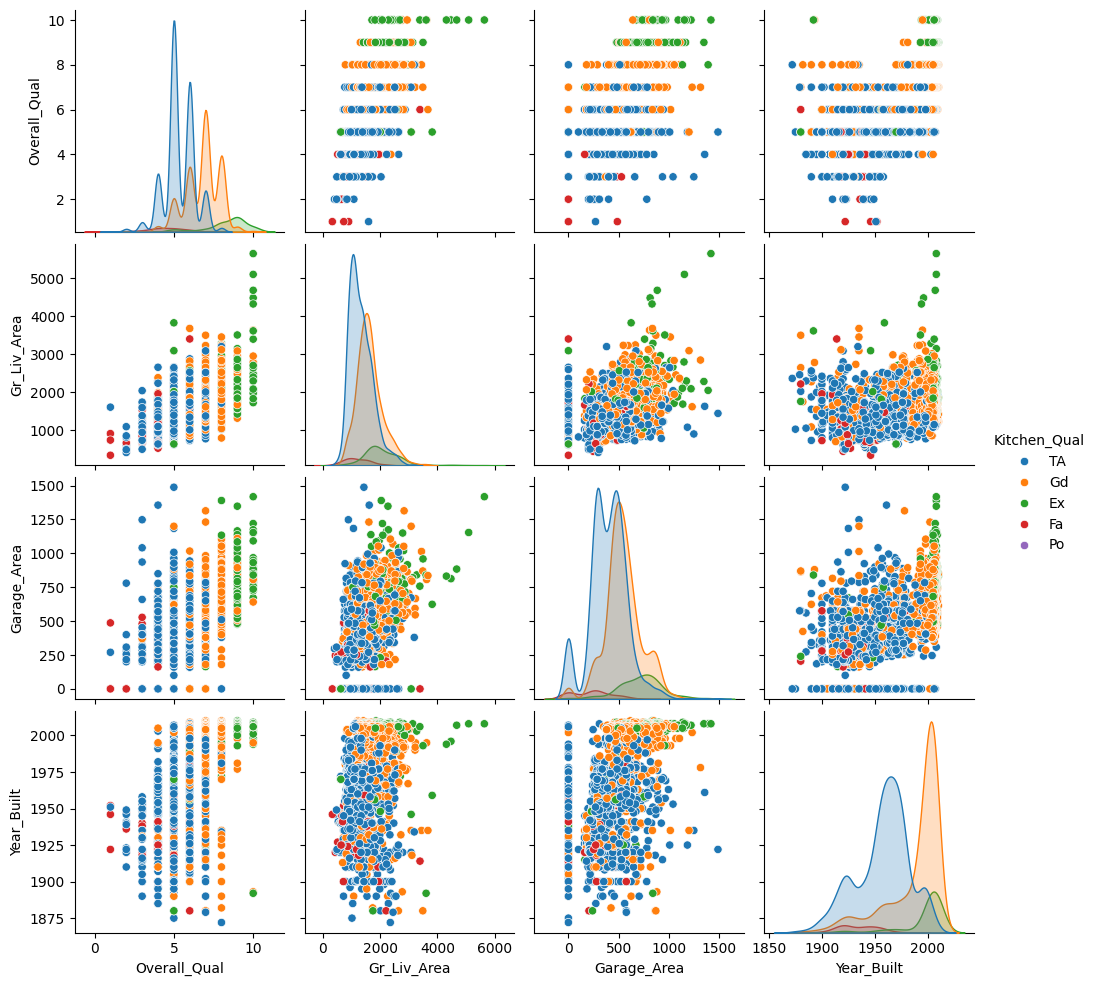

In [223]:
sns.pairplot(df,
             vars=['Overall_Qual', 'Gr_Liv_Area',
                   'Garage_Area','Year_Built'],
            hue='Kitchen_Qual')
plt.show()

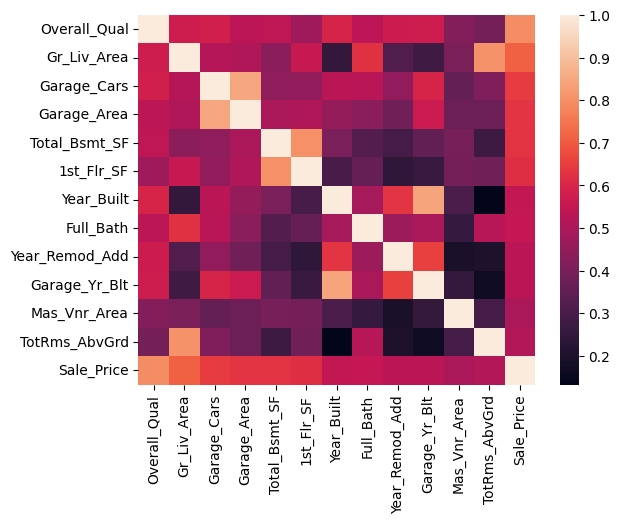

In [232]:
df_corr = df.dropna().corr(numeric_only=True)     
sns.heatmap(df_corr)
plt.show()

## 5: Ask a Question about the data

What drives house prices in Ames?


In [259]:
corr = df.corr(numeric_only=True)['Sale_Price'].sort_values(ascending=False)
top_features = corr[1:6].index
top_features

Index(['Overall_Qual', 'Gr_Liv_Area', 'Garage_Cars', 'Garage_Area',
       'Total_Bsmt_SF'],
      dtype='str')

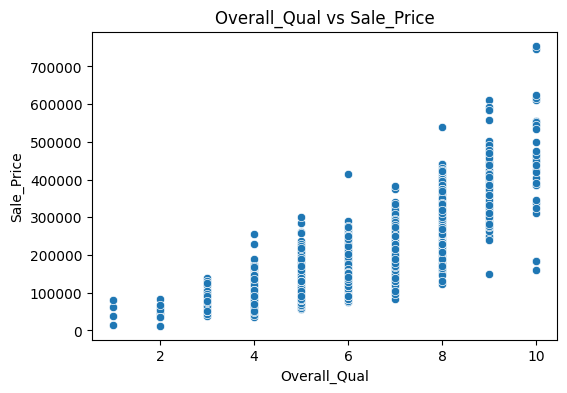

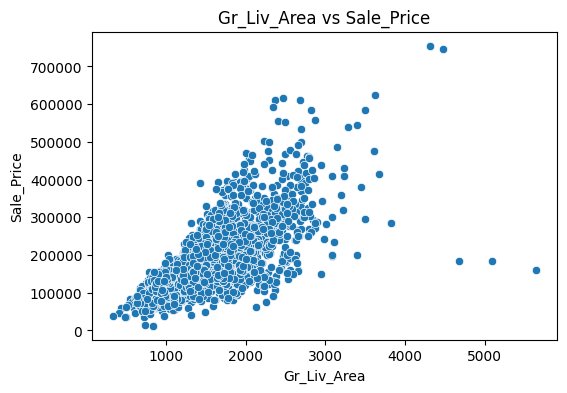

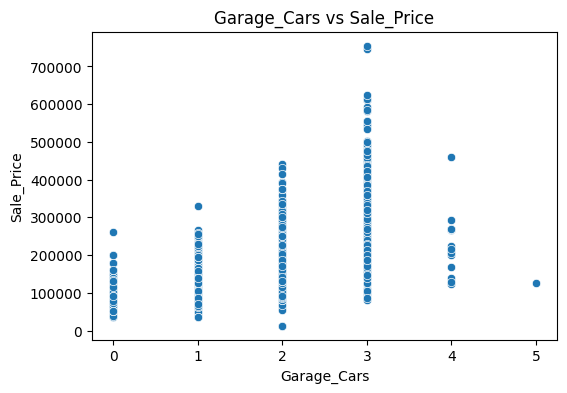

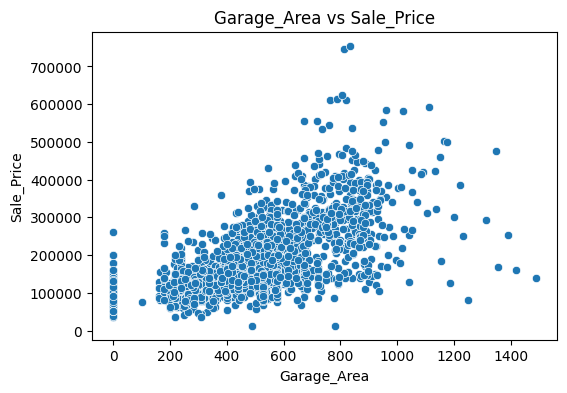

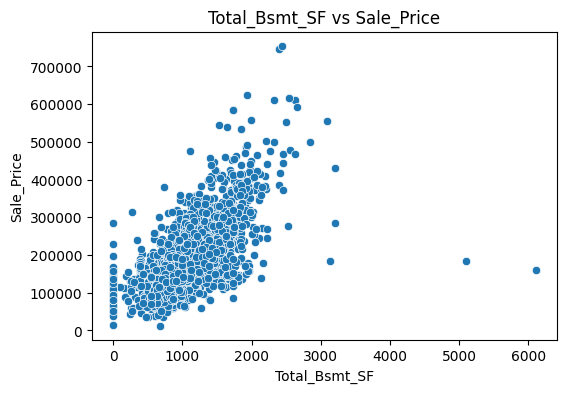

In [245]:
for feature in top_features:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=feature, y='Sale_Price', data=df)
    plt.title(f'{feature} vs Sale_Price')
    plt.show()

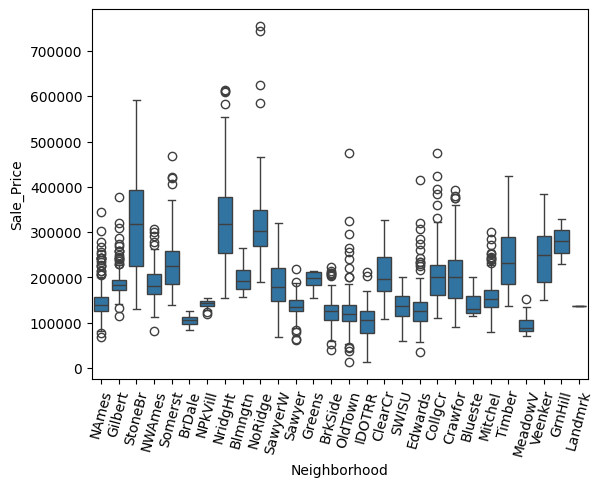

In [255]:
sns.boxplot(x='Neighborhood', y='Sale_Price', data=df)
plt.xticks(rotation=75)
plt.show()

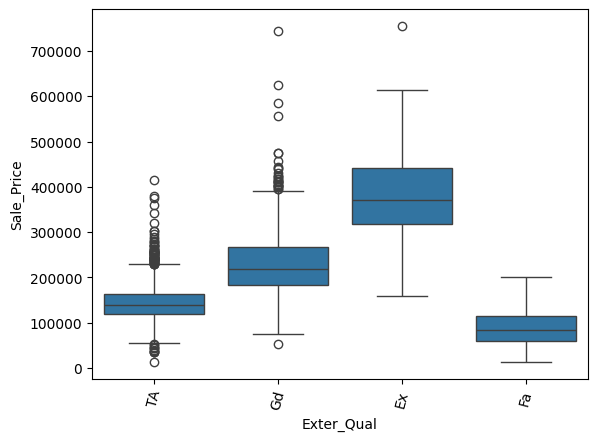

In [256]:
sns.boxplot(x='Exter_Qual', y='Sale_Price', data=df)
plt.xticks(rotation=75)
plt.show()

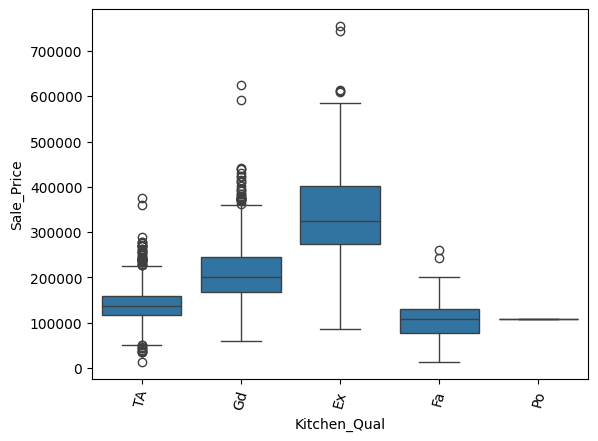

In [257]:
sns.boxplot(x='Kitchen_Qual', y='Sale_Price', data=df)
plt.xticks(rotation=75)
plt.show()

### My Answer:

This 3 drives house prices most in Ames:

- Size of Living Area -  Shows a very strong possitive relationship with price, suggesting larger living areas command higher market value.
- Neighbourhood- Price ranges and price averages for differnet neighbourhood varies by a lot, suggesting which neighbourhiid the house is locates matter a lot for price.
- Overall quality - Home with better overall quality have been sold at higher price, and it has a positive relationship with Sale Price.

These features show strong associations with SalePrice, though correlation does not imply direct causation.